# Taller S2 · CONECTA S.A., Grupo \# 1

**Curso:** Visualización de Datos y Gerencia de la Información (UNAULA)

**Integrantes:** _(nombres aquí)_

**Grupo:** _(número aquí, y también en el nombre del archivo: `v0.1_s2_dataviz_grupoN.ipynb`)_

## Propósito

Experimentar con distintos tipos de gráfico para la misma pregunta y comparar cuál comunica mejor, en vez de aplicar una sola técnica por variable. La meta no es llegar rápido a un gráfico final, es probar y descartar con criterio.

Cada actividad pide construir más de un gráfico para la misma pregunta. No hay una respuesta correcta única: lo que se evalúa es la comparación y la justificación de cuál prefieren y por qué.

## Cómo usar este notebook

1. Dupliquen este archivo y renómbrenlo con el número de su grupo (por ejemplo `v0.1_s2_dataviz_grupo3.ipynb`).
2. En la celda de configuración de abajo, cambien `GRUPO` por su número (1 a 5) para cargar el archivo correcto.
3. Completen cada actividad en las celdas marcadas con `# TODO`. Las celdas de conclusión siguen el patrón que ya conocen: bullets basados en los números y gráficos que obtuvieron, cerrando con la pregunta de "Para pensar".
4. **Entregable:** este mismo notebook, con la tabla de clasificación y las siete actividades resueltas.

## 0. Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.float_format", lambda x: f"{x:.2f}")

GRUPO = 1  # cambien este número por el de su grupo (1 a 5)

df = pd.read_csv(f"conecta_sa_grupo{GRUPO}.csv")
df.head()

,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


### Una función que van a necesitar varias veces

`region` y `plan_type` traen variantes de escritura (mayúsculas, tildes faltantes, espacios extra). ¿Cómo lo solucionarían? A continuación, una propuesta:

In [2]:
def normalizar_texto(valor):
    texto = str(valor).strip().upper()
    for con_tilde, sin_tilde in [("Á", "A"), ("É", "E"), ("Í", "I"), ("Ó", "O"), ("Ú", "U")]:
        texto = texto.replace(con_tilde, sin_tilde)
    return texto.title()

df["region_n"] = df["region"].apply(normalizar_texto)
df["tier_n"] = df["tier_localidad"].apply(normalizar_texto)
df[["region", "region_n", "tier_localidad", "tier_n"]].head()

,region,region_n,tier_localidad,tier_n
0,Caribe,Caribe,Media,Media
1,Andina,Andina,Baja,Baja
2,Caribe,Caribe,Media,Media
3,Andina,Andina,Media,Media
4,Andina,Andina,Alta,Alta


## 1. Clasificación de columnas

**Propósito:** para cada columna del dataset de su grupo, completen la tabla: nombre de columna, tipo de dato (numérico continuo, categórico, temporal, geoespacial), y gráfico recomendado. Esta tabla guía las siguientes seis actividades, tómense el tiempo de hacerla bien antes de graficar nada.

In [3]:
df.dtypes

user_id                     str
mes                         str
pais                        str
region                      str
ciudad                      str
localidad                   str
tier_localidad              str
latitud                 float64
longitud                float64
plan_type                   str
signup_date                 str
tenure_months             int64
es_cliente_nuevo_mes       bool
monthly_revenue_cop     float64
data_usage_gb           float64
complaints_month          int64
nps_score               float64
churned                   int64
churn_type                  str
churn_date                  str
region_n                    str
tier_n                      str
dtype: object

Completen la columna de tipo de dato y gráfico recomendado:

| columna | tipo de dato | gráfico recomendado | Pregunta que puedes responder | 
|---|---|---|---|
| `user_id` | texto - no aplica| Lineas con mes|
| `mes` | fecha-discreto| Lineas con Churn  |
| `pais` |texto-categorico | Heatmap con región|
| `region` | texto-categorico| Barras apiladas con Churn|
| `ciudad` | texto-categorico| top 10 con churn|
| `localidad` | texto-categorico| treemap con tier_localidad|
| `tier_localidad` |cualitativo | treemap con localidad||
| `latitud` | geoespacial| map|
| `longitud` | geoespacial| map|
| `plan_type` |cualitativo-sin orden | Pie||
| `signup_date` | fecha-continuo| Lineas con nps score|
| `tenure_months` | numerico - discreto| bubble char monthly_revenue_cop + churned |
| `es_cliente_nuevo_mes` |cualitativo |Violin plot con data_usage_gb |  | 
| `monthly_revenue_cop` | numerico- discreto| box plot con es_cliente_nuevo_mes|¿Los clientes nuevos pagan montos diferentes a los clientes antiguos?|
| `data_usage_gb` | numerico -continuo| Violin plot con tier_localidad |¿Cómo cambia el consumo según el tier de localidad?|
| `complaints_month` | numerico-discreto| box plot con plan_type |¿Cómo varía la cantidad de quejas según el tipo de plan?|
| `nps_score` | Numerico-continuo| Box plot con churn|¿Los clientes que abandonaron tenían niveles de satisfacción diferentes?|
| `churned` | cualitativo| donut con tier_localidad|¿Cómo cambia la proporción de churn según el tier?|
| `churn_type` | texto-categorico| heat map con plan_type |¿Existen tipos de plan asociados con determinados tipos de churn?|
| `churn_date` | fecha-continuo| Linea con user_id|¿En qué fechas se concentraron más abandonos?|

**Para pensar:** ¿hay alguna columna que podrían clasificar de más de una forma según la pregunta que le hagan? ¿Cuál, y cuáles serían esas dos preguntas distintas?

## 2. Cantidades, de tres formas

**Propósito:** respondan “¿cómo se distribuyen los usuarios entre las 5 regiones?” con tres gráficos distintos: barras verticales, un gráfico de puntos (dot plot), y un heatmap cruzando `region` con `tier_localidad`.

Este dataset es un panel: un mismo usuario puede aparecer en varias filas (un mes por fila). Para contar “usuarios” sin inflar el número, tomen un usuario por fila antes de agrupar, por ejemplo quedándose con la fila más reciente de cada `user_id`.

<Axes: title={'center': 'Grafica 1: Usaurios unicos por región'}, xlabel='region_n'>

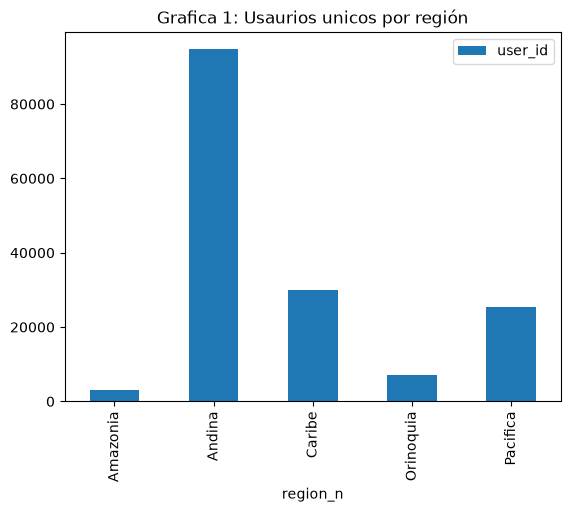

In [4]:
# Gráfico 1: barras verticales, usuarios únicos por región
# TODO: agrupen por region_n, cuenten usuarios únicos, grafiquen con plt.bar
# Verifiquen que el eje y incluya el cero

df[['user_id','region_n']].drop_duplicates().groupby('region_n').count().plot(
    kind='bar',
    title='Grafica 1: Usaurios unicos por región')
    

<Axes: title={'center': 'Grafico 2: Usuarios unicos por region (dot plot)'}, xlabel='region_n'>

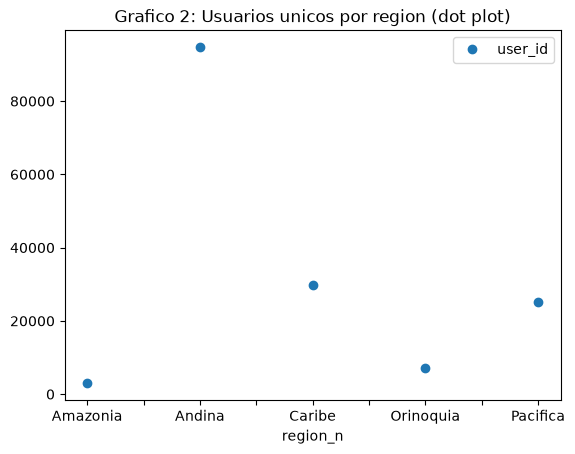

In [5]:
# Gráfico 2: dot plot, la misma cuenta pero como puntos
# TODO: mismos datos que el gráfico 1, con plt.scatter o plt.plot(marker="o", linestyle="none")

df[['user_id','region_n']].drop_duplicates().groupby('region_n').count().plot(
    marker="o", linestyle="none",
    title='Grafico 2: Usuarios unicos por region (dot plot)'
    )

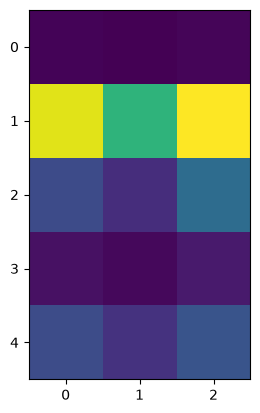

In [6]:


# Gráfico 3: heatmap region x tier_localidad
# TODO: tabla cruzada con pd.crosstab(df["region_n"], df["tier_n"]), graficada con plt.imshow
import seaborn as sns

import matplotlib.pyplot as plt

grafico_3 = pd.crosstab(df["region_n"], df["tier_n"])

plt.imshow(grafico_3)

**Conclusión:** _(bullets aquí, basados en los números que obtuvieron arriba)_

**Para pensar:** ¿cuál usarían en un dashboard gerencial y cuál en uno técnico? ¿Por qué?

## 3. Asociaciones, de dos formas

**Propósito:** En la sesión construimos un scatter de `complaints_month` contra `data_usage_gb` (la relación que vimos en la teoría) la idea es buscar otras dos variables para buscar su relación y, por separado, un correlograma con todas las variables numéricas del dataset.

<Axes: xlabel='tenure_months', ylabel='complaints_month'>

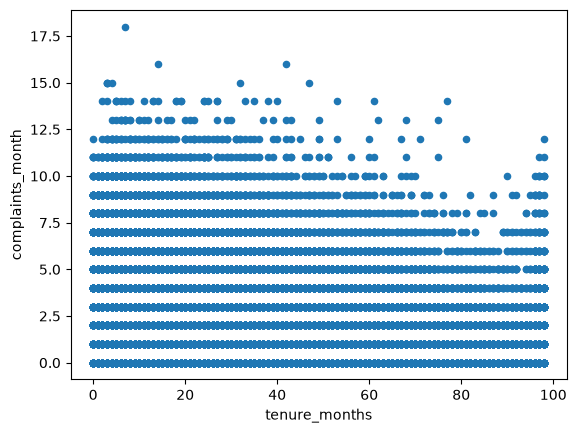

In [7]:
# Gráfico 1: scatter variable1 vs variable2
# TODO: plt.scatter(df["variable1"], df["variable2"], alpha=...)
#opción 1
#df[['complaints_month','monthly_revenue_cop']].plot(kind='scatter',y='complaints_month',x='monthly_revenue_cop')

#opción 2
df[['complaints_month','tenure_months']].plot(kind='scatter',y='complaints_month',x='tenure_months')



In [1]:

# Gráfico 2: correlograma de las variables numéricas
# TODO: calculen df[columnas_numericas].corr() y grafiquen, por ejemplo con sns.heatmap(annot=True)
import seaborn as sns

sns.heatmap(data=df[['complaints_month','monthly_revenue_cop']])


NameError: name 'df' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración estética global
sns.set_theme(style='whitegrid')

# ==========================================
# PARTE 1: Correlograma con variables numéricas
# ==========================================


def generar_correlograma(df):
  print('--- Generando Correlograma de Variables Numéricas ---')
  # Seleccionar únicamente las columnas de tipo numérico
  df_num = df.select_dtypes(include=[np.number])

  if df_num.empty:
    print('No hay suficientes variables numéricas para el correlograma.')
    return

  plt.figure(figsize=(10, 8))
  # Calculamos la matriz de correlación
  corr = df_num.corr()

  # Mapa de calor (heatmap)
  sns.heatmap(
      corr,
      annot=True,
      cmap='coolwarm',
      fmt='.2f',
      linewidths=0.5,
      vmin=-1,
      vmax=1,
      cbar_kws={'label': 'Coeficiente de Correlación'},
  )
  plt.title(
      'Correlograma - Matriz de Correlación de Pearson',
      fontsize=14,
      pad=15,
  )
  plt.tight_layout()
  plt.show()


# ==========================================
# PARTE 2: Gráficos de dispersión con manejo de errores
# ==========================================


def explorar_relaciones_scatter(df, columna_base):
  print(
      f'\n--- Buscando relaciones tipo Scatter usando la columna base:'
      f' "{columna_base}" ---'
  )

  if columna_base not in df.columns:
    print(f"Error crítico: La columna '{columna_base}' no existe en el dataset.")
    return

  # Iteramos sobre las demás columnas del DataFrame
  for col in df.columns:
    if col == columna_base:
      continue

    try:
      # Verificamos si ambas columnas son estrictamente numéricas para un scatter plot
      es_base_num = pd.api.types.is_numeric_dtype(df[columna_base])
      es_col_num = pd.api.types.is_numeric_dtype(df[col])

      if not (es_base_num and es_col_num):
        # Forzamos una excepción personalizada para activar el bloque except
        raise TypeError(
            f"Tipo de dato incompatible ('{columna_base}':"
            f' {df[columna_base].dtype}, \'{col}\': {df[col].dtype})'
        )

      # Si son numéricas, generamos el scatter plot
      plt.figure(figsize=(6, 4))
      sns.scatterplot(
          data=df, x=columna_base, y=col, alpha=0.6, color='royalblue'
      )

      plt.title(f'Relación: {columna_base} vs {col}', fontsize=11)
      plt.xlabel(columna_base)
      plt.ylabel(col)
      plt.tight_layout()
      plt.show()

    except Exception as e:
      # Capturamos el error (ej. columnas categóricas, texto, fechas) y mostramos mensaje
      plt.close()  # Cerramos la figura vacía si llegó a crearse
      print(
          f"[Aviso] No se pudo generar scatter plot entre '{columna_base}' y"
          f" '{col}'. Motivo: {e}"
      )



--- Generando Correlograma de Variables Numéricas ---


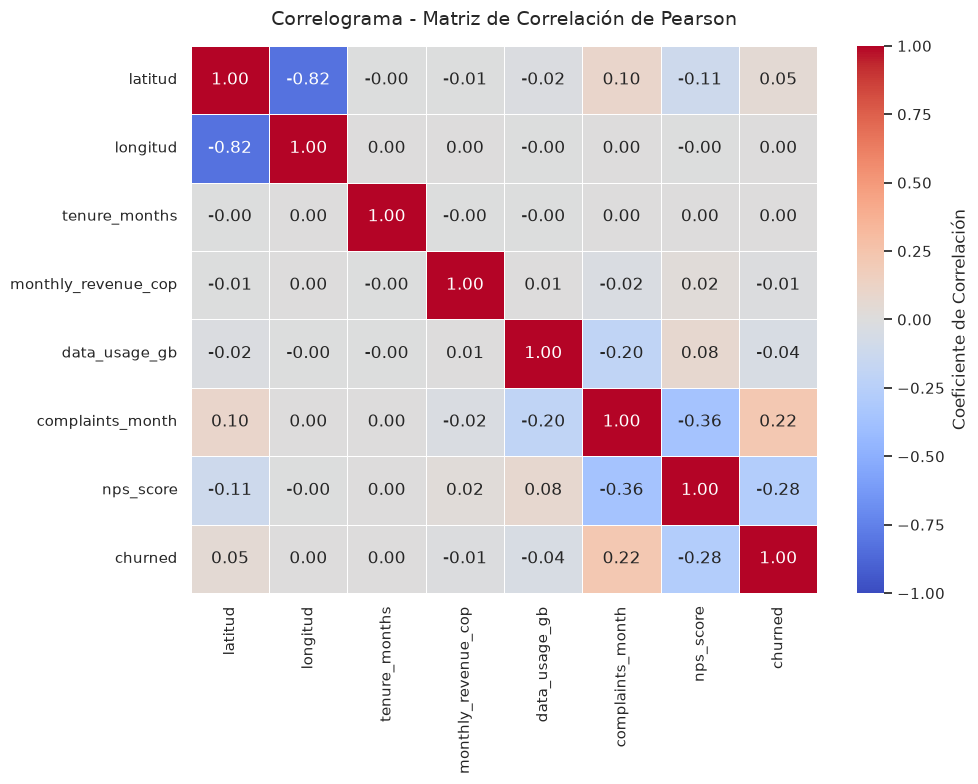


--- Buscando relaciones tipo Scatter usando la columna base: "tenure_months" ---
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'user_id'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'user_id': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'mes'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'mes': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'pais'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'pais': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'region'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'region': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'ciudad'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'ciudad': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'localidad'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'localidad': str)
[Aviso] No se pudo generar scatt

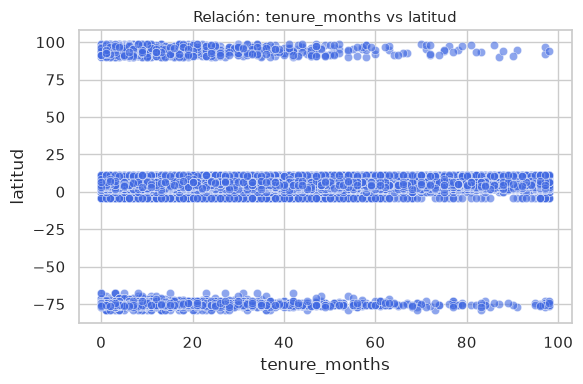

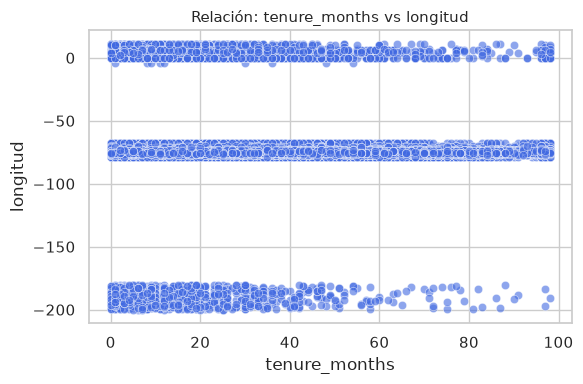

[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'plan_type'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'plan_type': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'signup_date'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'signup_date': str)


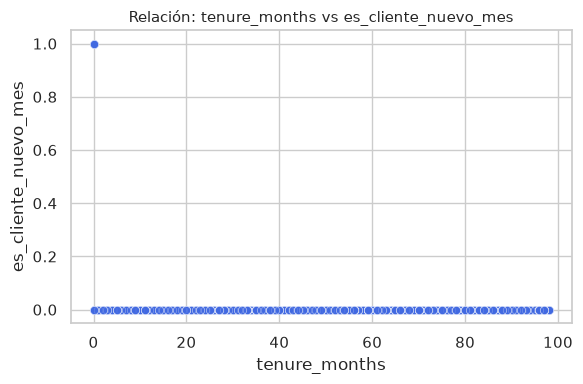

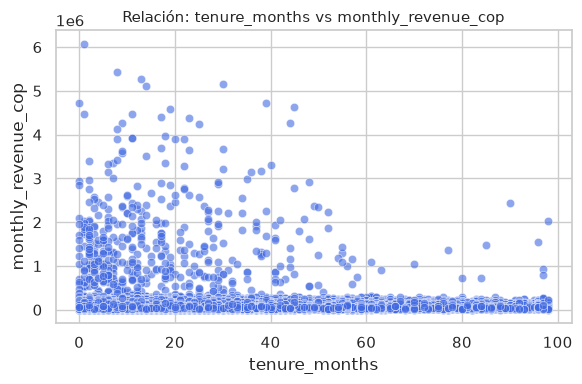

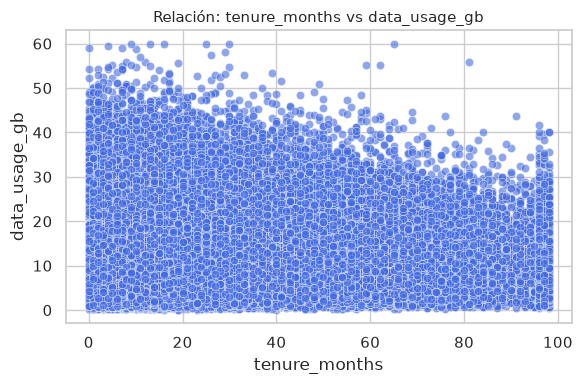

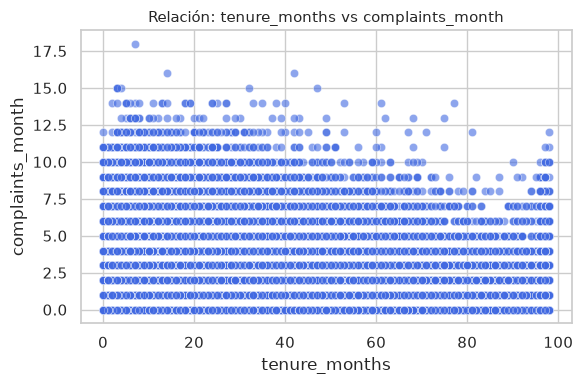

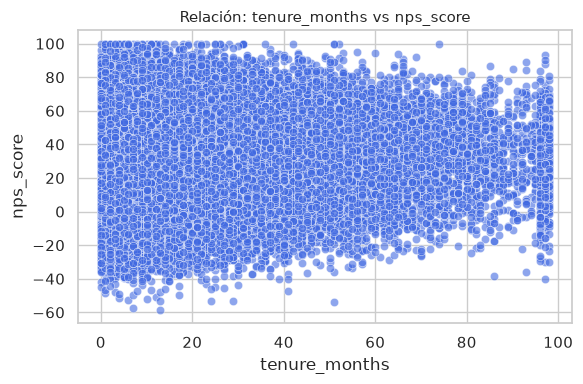

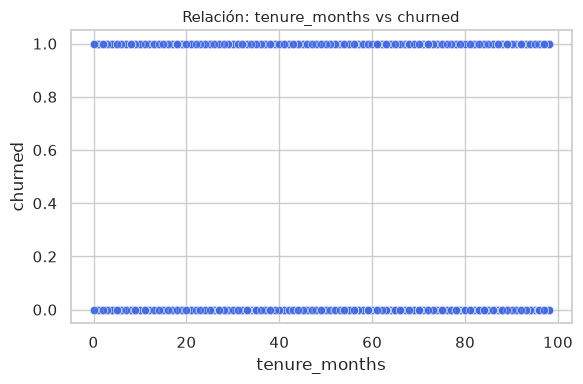

[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'churn_type'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'churn_type': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'churn_date'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'churn_date': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'region_n'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'region_n': str)
[Aviso] No se pudo generar scatter plot entre 'tenure_months' y 'tier_n'. Motivo: Tipo de dato incompatible ('tenure_months': int64, 'tier_n': str)


In [ ]:

# ==========================================
# EJEMPLO DE USO (Asumiendo que cargas tu df)
# ==========================================

generar_correlograma(df)
explorar_relaciones_scatter(df, "tenure_months")

**Conclusión:** _(bullets aquí, basados en los números que obtuvieron arriba)_

**Para pensar:** ¿el correlograma confirma o contradice lo que vieron en el scatter? ¿Qué otra relación les llamó la atención del correlograma que no habían considerado?

## 4. El tiempo, de dos formas

**Propósito:** construyan una línea de evolución mensual (usuarios activos o tasa de churn, marzo a mayo) y, por separado, un slope graph que compare solo marzo contra mayo por región.

La columna `mes` es texto (por ejemplo `"2026-03"`). Ordenarla como texto ya funciona porque el formato es año-mes, pero si prefieren fechas reales pueden convertirla con `pd.to_datetime`.

In [ ]:
# Gráfico 1: línea de evolución mensual (usuarios activos o tasa de churn)
# TODO: agrupen por mes, calculen la métrica elegida, grafiquen con plt.plot


# Gráfico 2: slope graph, marzo vs. mayo, por región
# TODO: para cada región, un punto en marzo y otro en mayo, unidos por una línea
# (dos posiciones fijas en el eje x, plt.plot([0, 1], [valor_marzo, valor_mayo]) por cada región)

**Conclusión:** _(bullets aquí, basados en los números que obtuvieron arriba)_

**Para pensar:** ¿cuál comunica mejor una tendencia sostenida? ¿Cuál comunica mejor un cambio puntual entre dos momentos?

## 5. Geoespacial, de dos formas

**Propósito:** construyan un mapa de puntos coloreado por alguna métrica (`churned`, `complaints_month`, o `monthly_revenue_cop`) y, por separado, un choropleth agregado por región para la misma métrica.

Las coordenadas traen algunos valores problemáticos: nulos, o fuera del rango de Colombia (latitud aproximadamente entre -4 y 13, longitud entre -79 y -66). Filtren esos casos antes del mapa de puntos, no hace falta corregirlos, alcanza con dejarlos por fuera para esta actividad.

Para el choropleth necesitan un polígono por región, no solo puntos. El archivo `data/geo/colombia_departamentos.geo.json` trae los 33 departamentos de Colombia; en la sesión ya vieron cómo agruparlos en las 5 regiones de CONECTA con un diccionario departamento → región y `.dissolve(by="region")`. Reutilicen ese mismo patrón.

In [ ]:
import geopandas as gpd

# Gráfico 1: mapa de puntos
# TODO: filtren coordenadas válidas y grafiquen plt.scatter(longitud, latitud, c=metrica, cmap=...)


# Gráfico 2: choropleth por región
# TODO: carguen data/geo/colombia_departamentos.geo.json, agrupen los departamentos en las 5 regiones
# de CONECTA (mismo patrón visto en la sesión), agreguen su métrica por region_n y grafiquen con .plot(column=...)

**Conclusión:** _(bullets aquí, basados en los números que obtuvieron arriba)_

**Para pensar:** ¿en qué punto el detalle del mapa de puntos deja de aportar y se vuelve ruido visual?

## 6. La trampa de `churn_type`

**Propósito:** construyan un gráfico de barras de `churn_type` tal cual viene la columna. Después, construyan una segunda versión que deje explícito qué fracción del total de usuarios representa cada barra, no solo de los que churnearon.

In [ ]:
# Gráfico 1: barras de churn_type tal cual
# TODO: df["churn_type"].value_counts().plot(kind="bar") o equivalente en matplotlib puro


# Gráfico 2: la misma barra, como fracción del total de usuarios (no solo de los que churnearon)
# TODO: dividan cada conteo entre el total de usuarios únicos del dataset, no entre el total de churneados

**Conclusión:** _(bullets aquí, basados en los números que obtuvieron arriba)_

**Para pensar:** ¿la primera versión puede llevar a una lectura equivocada? ¿Por qué?

## 7. Repitiendo lo avanzado, con su propio dataset

**Propósito:** la sesión ya mostró ridgeline (joypy), treemap (squarify) y error bars sobre CONECTA en general. Repitan **al menos dos** de esas tres técnicas con el dataset de su propio grupo.

### 7a. Ridgeline (joypy)

Un ridgeline de `monthly_revenue_cop` o `data_usage_gb`, por `mes` o por `tier_localidad`.

In [ ]:
import joypy

# TODO: joypy.joyplot(df, by=..., column=..., figsize=(8, 5), colormap=plt.cm.viridis)
# Revisen si necesitan recortar el eje (x_range) como en la demo, según qué tan larga
# sea la cola de valores altos en la columna que elijan

### 7b. Treemap (squarify)

Un treemap propio de `region` x `tier_localidad`, con los datos de su grupo: la combinación crítica de su grupo es distinta a la de la demo.

In [ ]:
import squarify

# TODO: agrupen por region_n y tier_n, cuenten usuarios únicos, ordenen de mayor a menor
# y grafiquen con squarify.plot(sizes=..., label=..., color=...)

### 7c. Error bars (opcional, si prefieren esta a una de las dos anteriores)

Promedio de `monthly_revenue_cop` o `data_usage_gb` por región, con intervalo de confianza.

In [ ]:
import scipy.stats as st

# TODO: agrupen por region_n, calculen mean, std, count, el error estándar y el IC 95%
# grafiquen con ax.errorbar(x, mean, yerr=ic95, fmt="o", capsize=5)

**Conclusión:** _(bullets aquí, basados en los números y gráficos de las dos técnicas que eligieron)_

**Para pensar:** ¿alguna de las dos técnicas que eligieron les reveló algo que no habían visto en las gráficas más simples de las actividades anteriores? ¿Cuál, y qué fue?

## Entregable

Este mismo notebook (`v0.1_s2_dataviz_grupoN.ipynb`, con su número de grupo). Antes de entregar, revisen: ¿cada conclusión está basada en los números y gráficos que de verdad obtuvieron?